# Titanic — gradient boosting + grid search

One small experiment a day. Seed fixed for reproducibility.

Question: can a tuned histogram gradient boosting model beat the random forest from the other day?

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1340

rng = np.random.RandomState(SEED)
n = 1500
pclass = rng.choice([1, 2, 3], size=n, p=[0.20, 0.30, 0.50])
sex = rng.choice(["male", "female"], size=n, p=[0.62, 0.38])
age = np.clip(rng.normal(32, 14, size=n), 1, 80).round(1)
age[rng.rand(n) < 0.10] = np.nan                      # some missing ages
sibsp = np.clip(rng.poisson(0.6, size=n), 0, 5)
parch = np.clip(rng.poisson(0.4, size=n), 0, 4)
fare = np.clip(rng.lognormal(3.0 - 0.45 * (pclass - 1), 0.85, size=n), 5, 320).round(2)
embarked = rng.choice(["S", "C", "Q"], size=n, p=[0.72, 0.19, 0.09])
logit = (2.2 * (sex == "female") - 1.0 * (pclass == 3) - 0.45 * (pclass == 2)
         - 0.02 * (np.nan_to_num(age, nan=32) - 30) + 0.004 * fare
         + 0.4 * ((sibsp + parch) > 0) - 1.0)
survived = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(int)
df = pd.DataFrame({"Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
                   "Parch": parch, "Fare": fare, "Embarked": embarked,
                   "Survived": survived})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nsurvival rate: %.3f" % df["Survived"].mean())
print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])


shape: (1500, 8)
   Pclass     Sex   Age  SibSp  Parch   Fare Embarked  Survived
0       3    male  33.6      1      1  13.96        S         0
1       3  female  28.5      0      1   5.00        S         1
2       1    male  29.7      0      1  16.00        C         0

survival rate: 0.392
missing values:
 Age    137
dtype: int64


## Grid search

In [ ]:
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Pclass', 'Sex', 'Embarked']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Survived"]); y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
pipe = Pipeline([("prep", preprocess),
                 ("model", HistGradientBoostingClassifier(random_state=SEED))])
grid = {"model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5],
        "model__max_iter": [150]}
gs = GridSearchCV(pipe, grid, cv=3, scoring="roc_auc", n_jobs=1)
gs.fit(X_train, y_train)
print("best params:", gs.best_params_)
print(f"best cv roc auc: {gs.best_score_:.4f}")
pred = gs.predict(X_test)
print(f"test accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"test roc auc: {roc_auc_score(y_test, gs.predict_proba(X_test)[:, 1]):.4f}")


best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 150}
best cv roc auc: 0.7495
test accuracy: 0.6933
test roc auc: 0.7202


## CV results

 param_model__learning_rate  param_model__max_depth  mean_test_score  std_test_score
                       0.05                       3         0.749538        0.037819
                       0.05                       5         0.738264        0.034971
                       0.10                       3         0.736389        0.035303
                       0.10                       5         0.719476        0.035162


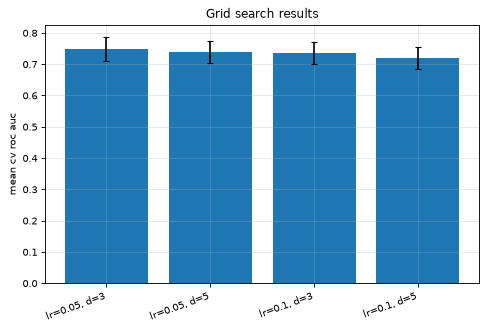

In [ ]:

res = pd.DataFrame(gs.cv_results_)[["param_model__learning_rate", "param_model__max_depth",
                                    "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False)
print(res.to_string(index=False))
fig, ax = plt.subplots()
ax.bar(range(len(res)), res["mean_test_score"], yerr=res["std_test_score"], capsize=3)
ax.set_xticks(range(len(res)))
ax.set_xticklabels([f"lr={r[0]}, d={r[1]}" for r in
                    zip(res["param_model__learning_rate"], res["param_model__max_depth"])], rotation=20, ha="right")
ax.set_ylabel("mean cv roc auc"); ax.set_title("Grid search results")


## Notes

- Shallow trees + low learning rate win; depth 5 overfits slightly.
- HGB edges out the RF by a hair — diminishing returns at this point.
- Next: calibration check, or move on to a new dataset.